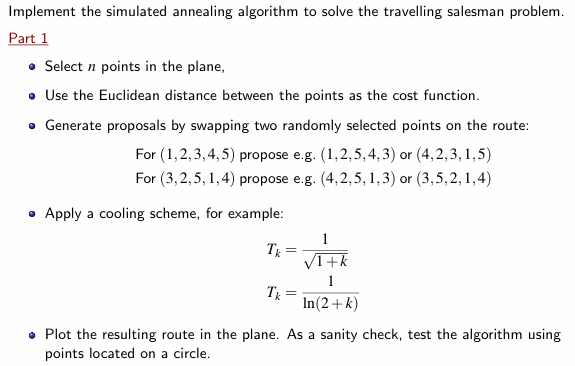

Circle:  best = 6.1803  (theory ≈ 6.2832)
Random:  best = 4.5359


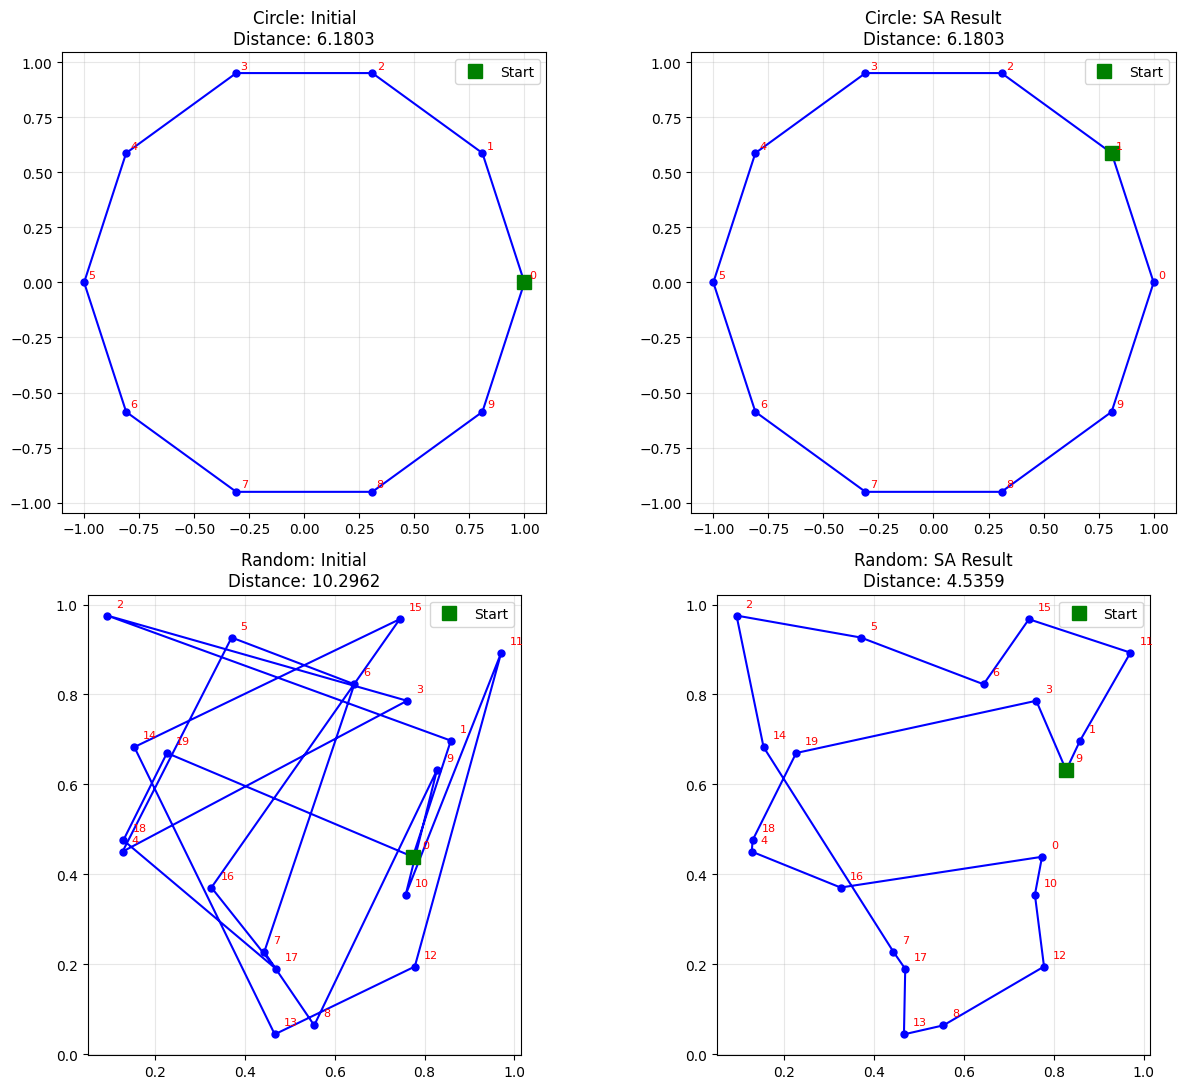

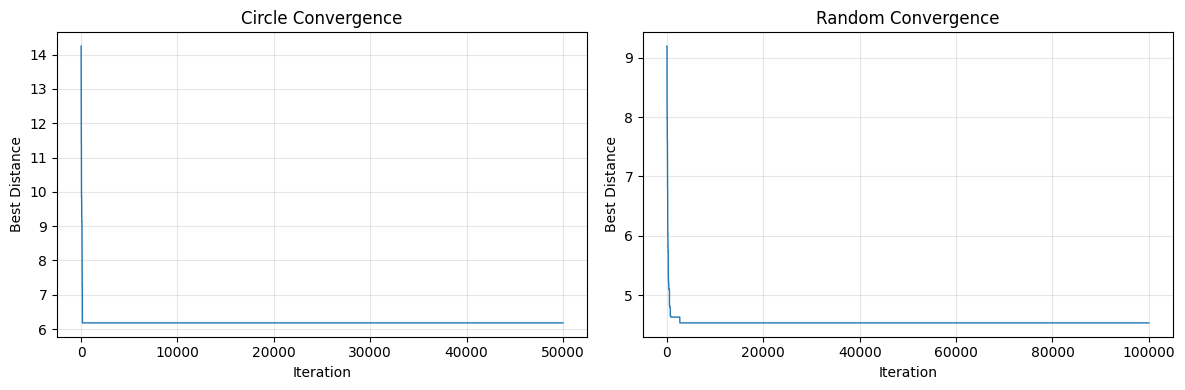

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import random

T_sqrt = lambda k: 1 / np.sqrt(1 + k)
T_log  = lambda k: 1 / np.log(2 + k)

def dist(p, q):
    return np.linalg.norm(p - q)

def tour_length(pts, route):
    n = len(route)
    return sum(dist(pts[route[i]], pts[route[(i+1)%n]]) for i in range(n))

def swap_prop(route):
    r = route.copy()
    i, j = random.sample(range(len(r)), 2)
    r[i], r[j] = r[j], r[i]
    return r

def sa_tsp(pts, max_iter=100_000, cooling=T_sqrt, seed=None):
    if seed:
        random.seed(seed); np.random.seed(seed)
    
    n = len(pts)
    cur = list(range(n))
    random.shuffle(cur)
    cur_len = tour_length(pts, cur)
    
    best, best_len = cur.copy(), cur_len
    hist = [best_len]
    
    for k in range(1, max_iter + 1):
        prop = swap_prop(cur)
        prop_len = tour_length(pts, prop)
        d = prop_len - cur_len
        
        if d < 0 or random.random() < np.exp(-d / cooling(k)):
            cur, cur_len = prop, prop_len
            if cur_len < best_len:
                best, best_len = cur.copy(), cur_len
        hist.append(best_len)
    
    return best, best_len, hist

n = 20
rng = np.random.default_rng(42)
random_pts = rng.random((n, 2))

m = 10
angles = np.linspace(0, 2*np.pi, m, endpoint=False)
circle_pts = np.column_stack((np.cos(angles), np.sin(angles)))

route_circ, len_circ, hist_circ = sa_tsp(circle_pts, 50_000, T_sqrt, seed=123)
route_rand, len_rand, hist_rand = sa_tsp(random_pts, 100_000, T_sqrt, seed=456)

print(f"Circle:  best = {len_circ:.4f}  (theory ≈ {2*np.pi:.4f})")
print(f"Random:  best = {len_rand:.4f}")

def plot_tsp(pts, route, title, ax):
    ordered = pts[route + [route[0]]]
    ax.plot(ordered[:,0], ordered[:,1], 'b-o', lw=1.5, ms=5)
    ax.plot(ordered[0,0], ordered[0,1], 'gs', ms=10, label='Start')
    for i, (x,y) in enumerate(pts):
        ax.text(x+0.02, y+0.02, str(i), fontsize=8, color='red')
    ax.set_title(f"{title}\nDistance: {tour_length(pts, route):.4f}")
    ax.set_aspect('equal'); ax.grid(True, alpha=0.3); ax.legend()

fig, axes = plt.subplots(2, 2, figsize=(13, 11))

plot_tsp(circle_pts, list(range(m)), "Circle: Initial", axes[0,0])
plot_tsp(circle_pts, route_circ, "Circle: SA Result", axes[0,1])
plot_tsp(random_pts, list(range(n)), "Random: Initial", axes[1,0])
plot_tsp(random_pts, route_rand, "Random: SA Result", axes[1,1])

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(hist_circ, lw=1); ax[0].set_title("Circle Convergence"); ax[0].set_xlabel("Iteration"); ax[0].set_ylabel("Best Distance"); ax[0].grid(True, alpha=0.3)
ax[1].plot(hist_rand, lw=1); ax[1].set_title("Random Convergence"); ax[1].set_xlabel("Iteration"); ax[1].set_ylabel("Best Distance"); ax[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

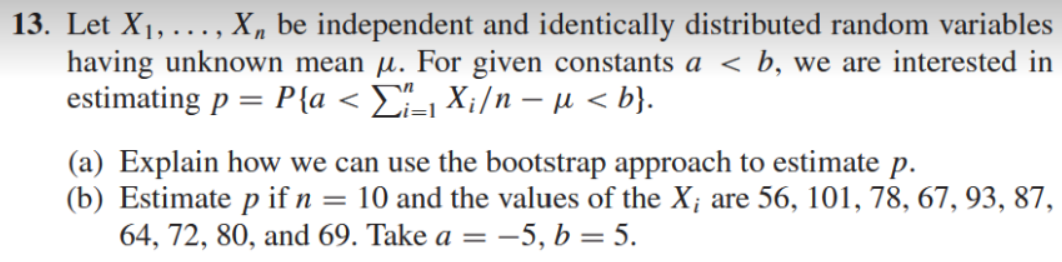

We are asked to estimate the probability that the difference in estimated vs. true mean lies within a bound given by $a < b$. We chose to estimate $\mu$ from the sample we are given and then estimate $\sum_{i=1}^nX_i/n$ as our bootstrap replicate via inverse EDF sampling. 

(b) We now proceed to implement the bootstrapping

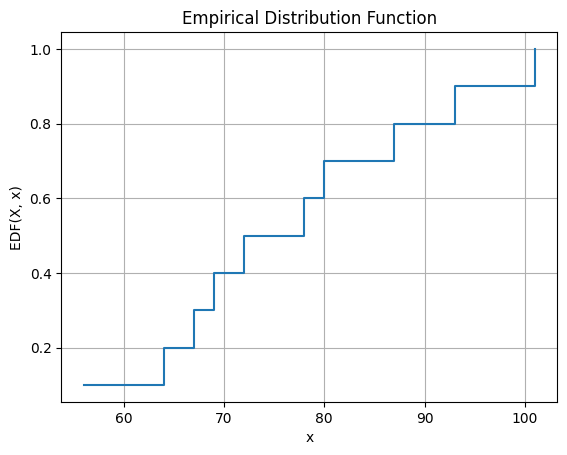

p =  77.5 %


In [ ]:
import numpy as np
import random
X = np.array([56,101,78,67,93,87,64,72,80,69])
a = -5
b = 5

n = 10
mu = np.mean(X)

def Inverse_EDF(X, p):
    sorted_X = np.sort(X)
    index = int(np.ceil(p * n)) - 1
    return sorted_X[index]

def bootstrap_sample_inverse(X):
    n = len(X)
    return np.array([Inverse_EDF(X, random.uniform(0, 1)) for _ in range(n)])

bootstrap_samples = [bootstrap_sample_inverse(X) for _ in range(1000)]

accepted = 0
for sample in bootstrap_samples:
    theta = np.mean(sample) - mu
    if a <= theta <= b:
        accepted += 1
print("p = ",(accepted / len(bootstrap_samples))*100, "%")

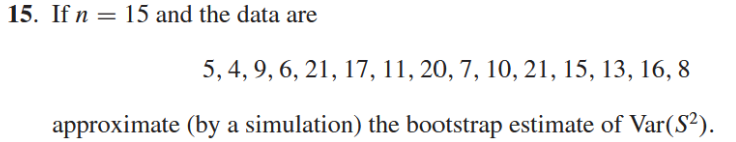

In [35]:
import numpy as np
import random
random.seed(42)
np.random.seed(42)
n = 15
X = np.array([5,4,9,6,21,17,11,20,7,10,21,15,13,16,8])

k = 1000

bootstrap_samples = [bootstrap_sample_inverse(X) for _ in range(k)]

var_estimates = []
for sample in bootstrap_samples:
    theta = np.var(sample, ddof=1)
    var_estimates.append(theta)
var_estimates = np.array(var_estimates)
mean_var_estimate = np.mean(var_estimates)
print("Mean of Variance Estimates: ", np.var(X, ddof=1))
variance_estimate = np.var(var_estimates, ddof=1)
print("Estimated Variance of the Variance Estimator: ", variance_estimate)

Mean of Variance Estimates:  34.31428571428571
Estimated Variance of the Variance Estimator:  56.68780166788104


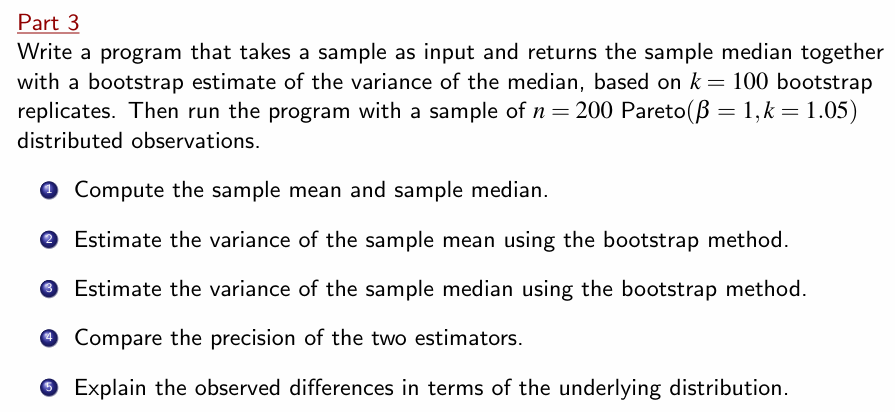

Sample Mean:  4.225954964437149
Sample Median:  1.914960542162116
Estimated Variance of the Sample Mean:  0.2776063673236822
Estimated Variance of the Sample Median:  0.022530789879032093


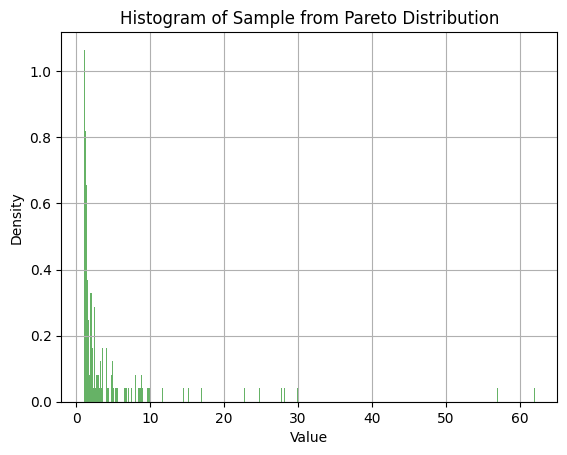

In [40]:
import numpy as np
import random
import matplotlib.pyplot as plt
import scipy as sp
# Set seed'
random.seed(42)
np.random.seed(42)
n = 200
k = 100

def sample_pareto(beta, k, size=1):
    U = np.random.uniform(0, 1, size=size)
    return k * (U ** (-1/beta))

X = sample_pareto(beta=1, k=1.05, size=200)
X = sp.stats.pareto.rvs(b=1.05, scale=1, size=200, random_state=42)
sample_mean = np.mean(X)
sample_median = np.median(X)
print("Sample Mean: ", sample_mean)
print("Sample Median: ", sample_median)

bootstrap_samples = [bootstrap_sample_inverse(X) for _ in range(100)]

mean_estimates = []
median_estimates = []
for sample in bootstrap_samples:
    mean_estimates.append(np.mean(sample))
    median_estimates.append(np.median(sample))

mean_var_estimate = np.var(mean_estimates, ddof=1)
median_var_estimate = np.var(median_estimates, ddof=1)
print("Estimated Variance of the Sample Mean: ", mean_var_estimate)
print("Estimated Variance of the Sample Median: ", median_var_estimate)

# plot sample
plt.hist(X, bins=500, density=True, alpha=0.6, color='g')
plt.title('Histogram of Sample from Pareto Distribution')
plt.xlabel('Value')
plt.ylabel('Density')
plt.grid()
plt.show()
